# Notebook 13: The Restoration Phase

The filter line search in notebook 11 can fail: after many halvings of the step
size, every candidate step is rejected.  This happens when the current iterate is
so **infeasible** that there is no descent direction that simultaneously reduces
both constraint violation and the barrier objective.

The solution is the **restoration phase**: temporarily forget the objective and
focus solely on recovering feasibility.  Once feasible, resume normal IPM steps.

ripopt implements a **two-phase** restoration strategy:
1. **Phase 1 — Gauss-Newton (GN)**: fast quadratic convergence for well-conditioned problems
2. **Phase 2 — NLP restoration**: a full IPM subproblem for difficult cases

**Learning objectives**
- Understand when and why the line search fails
- Derive the Gauss-Newton step for minimizing constraint violation
- Implement GN with rank-deficiency fallback and line search
- Understand the NLP restoration subproblem structure
- Visualize feasibility recovery

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lstsq, svd, solve

np.random.seed(7)
plt.rcParams['figure.dpi'] = 100

## 1. When Does the Line Search Fail?

The filter line search fails when every backtracking step produces a point that is:
- **Dominated** by some filter entry (both θ and φ worse), AND
- **Not Armijo** (φ didn't decrease enough)

This happens most often when the current iterate is deeply infeasible: the barrier
objective $\phi(x)$ doesn't decrease because the multipliers and Hessian are corrupted
by large constraint violations.

Let's construct such a failure scenario.

Starting point: x = [3. 4.]
Constraint violation θ = 24.00
KKT direction d = [-7.84  2.88]



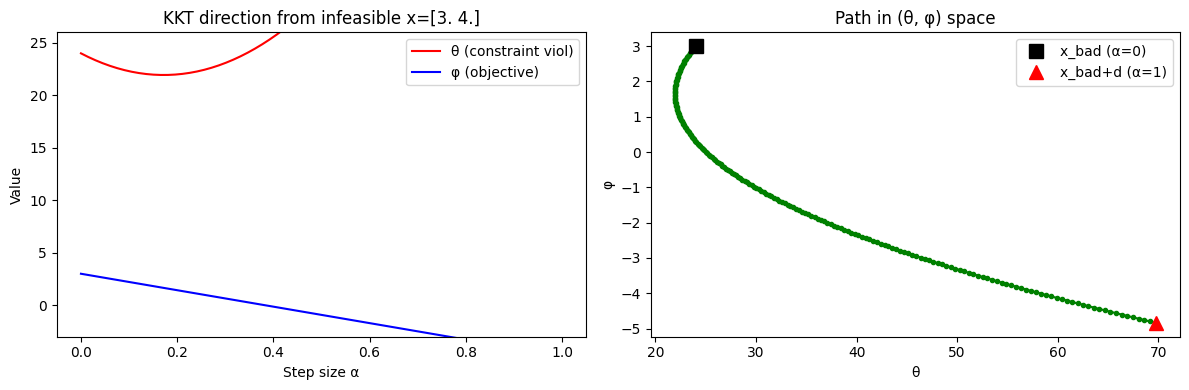

α=1.00: θ=69.760, φ=-4.840, theta_ok=False, phi_ok=True, accepted=True
α=0.50: θ=29.440, φ=-0.920, theta_ok=False, phi_ok=True, accepted=True
α=0.25: θ=22.360, φ=1.040, theta_ok=True, phi_ok=True, accepted=True
α=0.10: θ=22.298, φ=2.216, theta_ok=True, phi_ok=True, accepted=True
α=0.01: θ=23.767, φ=2.922, theta_ok=True, phi_ok=True, accepted=True


In [2]:
# Illustrate line search failure
# Problem: min x1  s.t.  x1^2 + x2^2 = 1  (optimal: x*=(-1,0), f*=-1)
# Start from a deeply infeasible point where the KKT direction doesn't help

def f_ex(x):
    return x[0]

def grad_f_ex(x):
    return np.array([1.0, 0.0])

def g_ex(x):
    return np.array([x[0]**2 + x[1]**2 - 1.0])

def jac_g_ex(x):
    return np.array([[2*x[0], 2*x[1]]])

def theta_ex(x):
    return float(np.abs(g_ex(x)[0]))

# Start from (3, 4): θ = |9+16-1| = 24
x_bad = np.array([3.0, 4.0])

# KKT direction (Newton step)
J = jac_g_ex(x_bad)
H = np.zeros((2, 2))  # Hessian = 0 for linear objective
K = np.block([[H + 0.1*np.eye(2), J.T], [J, np.zeros((1,1))]])
gf = grad_f_ex(x_bad)
gv = g_ex(x_bad)
rhs = np.concatenate([-gf, -gv])
sol = np.linalg.solve(K, rhs)
d_kkt = sol[:2]

print(f"Starting point: x = {x_bad}")
print(f"Constraint violation θ = {theta_ex(x_bad):.2f}")
print(f"KKT direction d = {d_kkt}")
print()

# Show theta and phi along the direction
alphas = np.linspace(0, 1.0, 200)
thetas_along = [theta_ex(x_bad + a*d_kkt) for a in alphas]
phis_along   = [f_ex(x_bad + a*d_kkt) for a in alphas]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(alphas, thetas_along, 'r-', label='θ (constraint viol)')
axes[0].plot(alphas, phis_along,   'b-', label='φ (objective)')
axes[0].set_xlabel('Step size α')
axes[0].set_ylabel('Value')
axes[0].set_title(f'KKT direction from infeasible x={x_bad}')
axes[0].legend()
axes[0].set_ylim(-3, 26)

axes[1].plot(thetas_along, phis_along, 'g-o', markersize=3)
axes[1].plot(thetas_along[0],  phis_along[0],  'ks', markersize=10, label='x_bad (α=0)')
axes[1].plot(thetas_along[-1], phis_along[-1], 'r^', markersize=10, label='x_bad+d (α=1)')
axes[1].set_xlabel('θ')
axes[1].set_ylabel('φ')
axes[1].set_title('Path in (θ, φ) space')
axes[1].legend()

plt.tight_layout()
plt.show()

# Check if any step along this direction would be filter-accepted
# (A very tight filter with current point)
theta_initial = theta_ex(x_bad)
phi_initial   = f_ex(x_bad)

for a in [1.0, 0.5, 0.25, 0.1, 0.01]:
    theta_trial = theta_ex(x_bad + a*d_kkt)
    phi_trial   = f_ex(x_bad + a*d_kkt)
    theta_ok = theta_trial <= (1 - 1e-5) * theta_initial
    phi_ok   = phi_trial   <= phi_initial - 1e-5 * theta_initial
    print(f"α={a:.2f}: θ={theta_trial:.3f}, φ={phi_trial:.3f}, "
          f"theta_ok={theta_ok}, phi_ok={phi_ok}, accepted={theta_ok or phi_ok}")

## 2. Gauss-Newton Restoration (Phase 1)

When the line search fails, we switch to minimizing constraint violation directly:
$$\min_x \; \theta(x) = \tfrac{1}{2}\|g(x)\|^2$$

The gradient is $\nabla\theta = J(x)^T g(x)$.

The **Gauss-Newton** approximation of the Hessian is $J^T J$ (ignoring the second-order
terms $\sum_i g_i \nabla^2 g_i$).  This gives the GN step:
$$J(x)^T J(x) \, d_{\text{gn}} = -J(x)^T g(x)$$
$$\Rightarrow \quad d_{\text{gn}} = -(J J^T)^{-1} J \, g \quad \text{(normal equations, m < n)}$$

This is the **minimum-norm** solution: $d_{\text{gn}} = -J^+ g$ where $J^+$ is the
pseudoinverse.  It has the nice property of lying in the **row space** of $J$,
meaning it's the shortest feasibility step.

In [3]:
def gauss_newton_step(x, g_fn, jac_g_fn, rcond_tol=1e-12):
    """
    Compute the Gauss-Newton step for minimizing (1/2)||g(x)||^2.

    d_gn = -J^+ g  where J^+ is the Moore-Penrose pseudoinverse.

    Falls back to gradient descent (d = -J^T g) when J is rank-deficient
    (indicated by very small singular values).

    Returns (d_gn, is_gradient_step, singular_values)
    """
    gv = g_fn(x)
    J  = jac_g_fn(x)
    m, n = J.shape

    # SVD to detect rank deficiency
    U, s, Vt = svd(J, full_matrices=False)

    # Check condition number
    max_sv = s[0] if len(s) > 0 else 1.0
    rank = np.sum(s > rcond_tol * max_sv)

    if rank == 0:
        # Jacobian is essentially zero — can't do anything
        return np.zeros(n), True, s

    if rank < min(m, n):
        # Rank-deficient: fall back to gradient descent step
        d_gn = -J.T @ gv
        norm_d = np.linalg.norm(d_gn)
        if norm_d > 0:
            d_gn = d_gn / norm_d  # normalize gradient step
        return d_gn, True, s

    # Full-rank: compute pseudoinverse via SVD
    # J^+ = V * diag(1/s) * U^T
    s_inv = np.where(s > rcond_tol * max_sv, 1.0 / s, 0.0)
    d_gn = -Vt.T @ (s_inv * (U.T @ gv))
    return d_gn, False, s


# Test on the example
d_gn, is_grad, svs = gauss_newton_step(x_bad, g_ex, jac_g_ex)
print(f"GN step from {x_bad}: d = {d_gn}")
print(f"  Is gradient step: {is_grad}")
print(f"  Singular values: {svs}")
print(f"  θ at x_bad:      {theta_ex(x_bad):.4f}")
print(f"  θ at x_bad+d_gn: {theta_ex(x_bad + d_gn):.4f}")
print()

# Test rank-deficiency fallback
x_degen = np.array([0.0, 0.0])  # Jacobian is zero here
d_degen, is_grad_d, svs_d = gauss_newton_step(x_degen, g_ex, jac_g_ex)
print(f"GN step from degenerate {x_degen}: d = {d_degen}")
print(f"  Is gradient step: {is_grad_d}")

GN step from [3. 4.]: d = [-1.44 -1.92]
  Is gradient step: False
  Singular values: [10.]
  θ at x_bad:      24.0000
  θ at x_bad+d_gn: 5.7600

GN step from degenerate [0. 0.]: d = [0. 0.]
  Is gradient step: True


## 3. GN Line Search on Constraint Violation

Once we have a GN direction $d$, we need to find a step size $\alpha$ that
sufficiently reduces the constraint violation:
$$\theta(x + \alpha d) \le (1 - 2\alpha\eta)\theta(x)$$
with $\eta = 10^{-4}$ (Armijo-like sufficient decrease on $\theta$).

In [4]:
def restoration_line_search(x, d, g_fn, jac_g_fn, theta_curr,
                             eta=1e-4, alpha_init=1.0, alpha_min=1e-10,
                             verbose=False):
    """
    Backtracking line search for GN restoration: reduce theta(x).

    Acceptance criterion:
        theta(x + alpha*d) <= (1 - 2*eta*alpha) * theta(x)

    Returns (alpha, theta_new, accepted)
    """
    alpha = alpha_init
    while alpha >= alpha_min:
        x_trial     = x + alpha * d
        theta_trial = np.linalg.norm(g_fn(x_trial))**2 / 2  # use ||g||^2/2 as theta
        sufficient  = (1 - 2 * eta * alpha) * theta_curr

        if verbose:
            print(f"  α={alpha:.2e}: θ_trial={theta_trial:.4e}, required≤{sufficient:.4e}")

        if theta_trial <= sufficient:
            return alpha, theta_trial, True

        alpha *= 0.5

    return alpha, theta_curr, False


# Test the GN line search
theta_sq_bad = np.linalg.norm(g_ex(x_bad))**2 / 2
print(f"theta (||g||^2/2) at x_bad = {theta_sq_bad:.4f}")

alpha_gn, theta_gn, ok = restoration_line_search(
    x_bad, d_gn, g_ex, jac_g_ex, theta_sq_bad, verbose=True
)
print(f"\nGN line search: α={alpha_gn:.4f}, θ_new={theta_gn:.4f}, accepted={ok}")
x_after_gn = x_bad + alpha_gn * d_gn
print(f"x after one GN step: {x_after_gn}")
print(f"θ reduced: {theta_sq_bad:.4f} → {theta_gn:.4f}")

theta (||g||^2/2) at x_bad = 288.0000
  α=1.00e+00: θ_trial=1.6589e+01, required≤2.8794e+02

GN line search: α=1.0000, θ_new=16.5888, accepted=True
x after one GN step: [1.56 2.08]
θ reduced: 288.0000 → 16.5888


## 4. Full Gauss-Newton Restoration

We iterate the GN step + line search until constraint violation falls below
the tolerance, or we give up and trigger Phase 2.

=== Demo 1: Restore from x_bad = (3, 4) ===
  iter   0: θ=2.880e+02, α=1.00e+00, θ_new=1.659e+01, type=GN
  iter   1: θ=1.659e+01, α=1.00e+00, θ_new=7.527e-01, type=GN
  iter   2: θ=7.527e-01, α=1.00e+00, θ_new=1.428e-02, type=GN
  iter   3: θ=1.428e-02, α=1.00e+00, θ_new=1.866e-05, type=GN
  iter   4: θ=1.866e-05, α=1.00e+00, θ_new=4.298e-11, type=GN
  iter   5: θ=4.298e-11, α=1.00e+00, θ_new=2.309e-22, type=GN
GN converged at iteration 6, θ = 2.31e-22

Restored to: [0.6 0.8]
Constraint violation at restored point: 2.15e-11
On unit circle? ||x||=1.000000


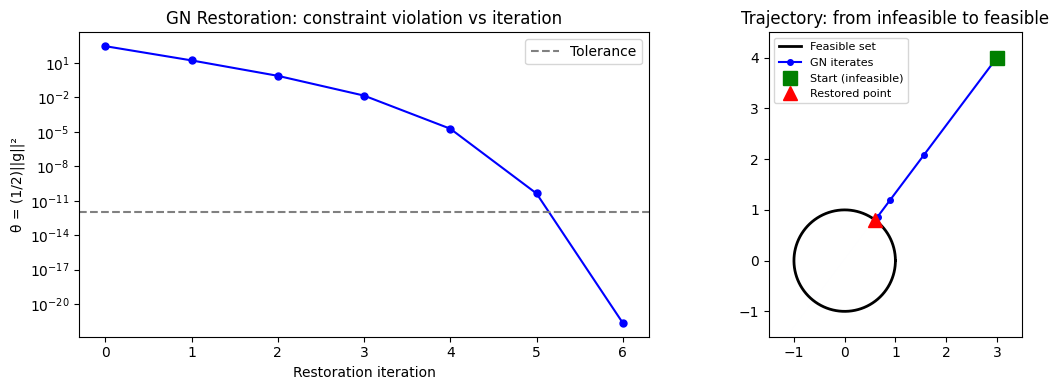

In [5]:
def gauss_newton_restoration(x0, g_fn, jac_g_fn,
                              max_iter=50, tol=1e-8,
                              alpha_init=1.0, verbose=False):
    """
    Gauss-Newton restoration: minimize (1/2)||g(x)||^2 to tol.

    Returns
    -------
    x_restored : ndarray
    converged  : bool
    history    : list of dict with 'theta', 'alpha', 'is_grad_step'
    """
    x = x0.copy()
    history = []

    for iteration in range(max_iter):
        gv    = g_fn(x)
        theta = np.linalg.norm(gv)**2 / 2

        history.append({'iter': iteration, 'theta': theta, 'alpha': None,
                        'is_grad_step': False, 'x': x.copy()})

        if theta < tol:
            if verbose:
                print(f"GN converged at iteration {iteration}, θ = {theta:.2e}")
            return x, True, history

        d, is_grad, _ = gauss_newton_step(x, g_fn, jac_g_fn)

        if np.linalg.norm(d) < 1e-14:
            if verbose:
                print(f"GN stalled at iteration {iteration} (zero step)")
            return x, False, history

        alpha, theta_new, ls_ok = restoration_line_search(
            x, d, g_fn, jac_g_fn, theta, alpha_init=alpha_init
        )
        history[-1]['alpha']        = alpha
        history[-1]['is_grad_step'] = is_grad

        if verbose:
            step_type = 'gradient' if is_grad else 'GN'
            print(f"  iter {iteration:3d}: θ={theta:.3e}, α={alpha:.2e}, "
                  f"θ_new={theta_new:.3e}, type={step_type}")

        if not ls_ok:
            if verbose:
                print(f"GN line search failed at iteration {iteration}")
            return x, False, history

        x = x + alpha * d

    return x, False, history


# Demo 1: Restore from deeply infeasible point
print("=== Demo 1: Restore from x_bad = (3, 4) ===")
x_rest, converged, hist = gauss_newton_restoration(
    x_bad, g_ex, jac_g_ex, max_iter=30, tol=1e-12, verbose=True
)
print(f"\nRestored to: {x_rest}")
print(f"Constraint violation at restored point: {np.abs(g_ex(x_rest)[0]):.2e}")
print(f"On unit circle? ||x||={np.linalg.norm(x_rest):.6f}")

# Plot convergence
thetas_hist = [h['theta'] for h in hist]
grad_steps  = [h['is_grad_step'] for h in hist]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(range(len(thetas_hist)), thetas_hist, 'b-o', markersize=5)
for i, gs in enumerate(grad_steps):
    if gs:
        axes[0].semilogy(i, thetas_hist[i], 'rx', markersize=12, markeredgewidth=2)
axes[0].set_xlabel('Restoration iteration')
axes[0].set_ylabel('θ = (1/2)||g||²')
axes[0].set_title('GN Restoration: constraint violation vs iteration')
axes[0].axhline(1e-12, color='gray', linestyle='--', label='Tolerance')
axes[0].legend()

# Show trajectory on the unit circle
theta_bg = np.linspace(0, 2*np.pi, 300)
axes[1].plot(np.cos(theta_bg), np.sin(theta_bg), 'k-', linewidth=2, label='Feasible set')
xs_rest = np.array([h['x'] for h in hist])
axes[1].plot(xs_rest[:, 0], xs_rest[:, 1], 'b-o', markersize=4, label='GN iterates')
axes[1].plot(xs_rest[0, 0], xs_rest[0, 1], 'gs', markersize=10, label='Start (infeasible)')
axes[1].plot(x_rest[0], x_rest[1], 'r^', markersize=10, label='Restored point')
axes[1].set_aspect('equal')
axes[1].set_xlim(-1.5, 3.5)
axes[1].set_ylim(-1.5, 4.5)
axes[1].legend(fontsize=8)
axes[1].set_title('Trajectory: from infeasible to feasible')

plt.tight_layout()
plt.show()

## 5. Gradient Descent Fallback for Rank-Deficient Jacobians

When $J(x)$ is rank-deficient, the GN step is undefined.  The fallback is to use
the steepest descent direction for $\theta$:
$$d_{\text{grad}} = -\nabla\theta(x) = -J(x)^T g(x)$$
This was critical for TP262 in ripopt's benchmark suite.

Near-degenerate case:
  J(x) = 
[[ 0.1  -1.  ]
 [ 0.1   0.05]]
  Singular values: [1.00578399 0.10439617]
  GN step: d = [-0.00119048 -0.09761905], is_gradient = False

g(x_start) = [1. 6.]
||g|| = 6.0828
Restored to: [0.04487749 0.00124525], ||g|| = 7.71e-04
Converged: True, iterations: 9, gradient fallback steps: 0


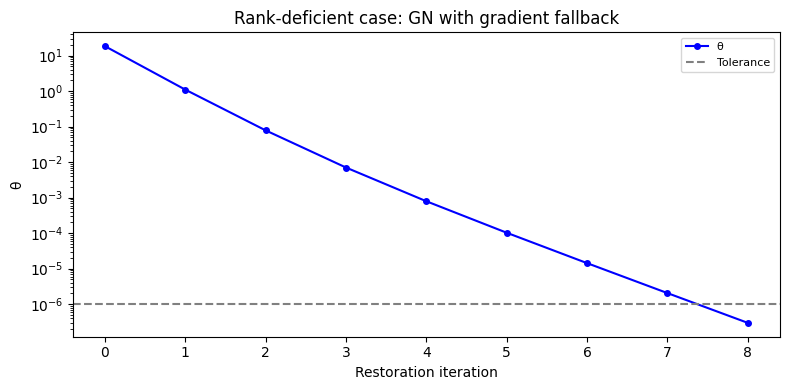

In [6]:
# Problem where Jacobian becomes rank-deficient during restoration
# g(x) = [x1^2 - x2, x1*x2]  — Jacobian rank-deficient when x1=x2=0

def g_rankdef(x):
    return np.array([x[0]**2 - x[1], x[0]*x[1]])

def jac_g_rankdef(x):
    return np.array([[2*x[0], -1.0], [x[1], x[0]]])

# Start near the degenerate point
x_near_degen = np.array([0.05, 0.1])
print("Near-degenerate case:")
print(f"  J(x) = \n{jac_g_rankdef(x_near_degen)}")
print(f"  Singular values: {svd(jac_g_rankdef(x_near_degen), compute_uv=False)}")

d_gn2, is_grad2, svs2 = gauss_newton_step(x_near_degen, g_rankdef, jac_g_rankdef)
print(f"  GN step: d = {d_gn2}, is_gradient = {is_grad2}")
print()

# Full restoration
x_start_rd = np.array([2.0, 3.0])
print(f"g(x_start) = {g_rankdef(x_start_rd)}")
print(f"||g|| = {np.linalg.norm(g_rankdef(x_start_rd)):.4f}")

# The feasible set is where x1^2=x2 AND x1*x2=0, so x1=0,x2=0
x_rest2, conv2, hist2 = gauss_newton_restoration(
    x_start_rd, g_rankdef, jac_g_rankdef, max_iter=100, tol=1e-6, verbose=False
)
thetas2 = [h['theta'] for h in hist2]
grad_steps2 = [h['is_grad_step'] for h in hist2]
n_grad = sum(grad_steps2)

print(f"Restored to: {x_rest2}, ||g|| = {np.linalg.norm(g_rankdef(x_rest2)):.2e}")
print(f"Converged: {conv2}, iterations: {len(hist2)}, gradient fallback steps: {n_grad}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy([h['theta'] for h in hist2], 'b-o', markersize=4, label='θ')
grad_iters = [i for i, gs in enumerate(grad_steps2) if gs]
if grad_iters:
    ax.semilogy(grad_iters, [thetas2[i] for i in grad_iters], 'rx',
                markersize=12, markeredgewidth=2, label='Gradient fallback step')
ax.axhline(1e-6, color='gray', linestyle='--', label='Tolerance')
ax.set_xlabel('Restoration iteration')
ax.set_ylabel('θ')
ax.set_title('Rank-deficient case: GN with gradient fallback')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. NLP Restoration Subproblem (Phase 2)

When GN restoration fails repeatedly, ripopt switches to a **full NLP subproblem**:

$$\min_{x, p, n \ge 0} \; \rho \sum_i (p_i + n_i) + \frac{\eta}{2} \|D_R(x - x_r)\|^2$$
$$\text{s.t.} \quad g(x) - p + n = g_{\text{target}}$$

Here:
- $p, n \ge 0$ are **slack variables** that relax the constraints
- $\rho > 0$ penalizes constraint violation (like $\ell_1$ exact penalty)
- $x_r$ is the reference (current) point and $D_R$ is a scaling matrix
- $g_{\text{target}}$ is the target constraint value (0 for equalities)

This subproblem is itself an NLP with bound constraints ($p, n \ge 0$).  ripopt
solves it with the same IPM, but with `disable_nlp_restoration=true` to prevent
infinite nesting.

We implement a simplified version in Python.

Starting from x = [5. 7.], ||g|| = 73.00
NLP restoration result: ||g|| = 7.30e+01, converged = False
Restored x = [5. 7.]


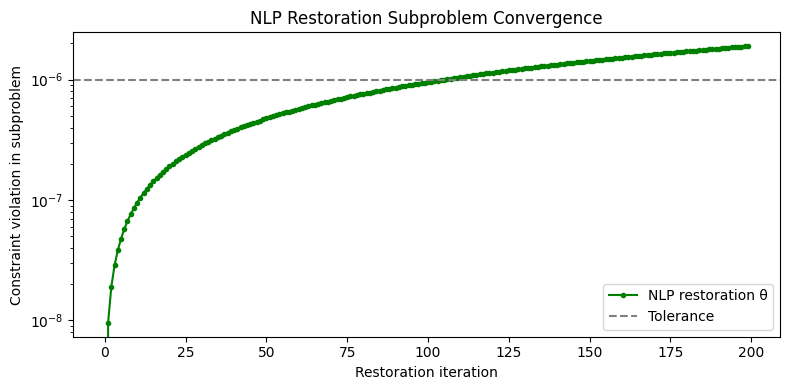

In [7]:
def nlp_restoration_subproblem(x_ref, g_fn, jac_g_fn, hess_g_fn=None,
                                rho=1e4, eta=1e-3, g_target=None,
                                max_iter=100, tol=1e-8):
    """
    NLP restoration subproblem (simplified):

        min rho*(sum(p+n)) + eta/2 * ||x - x_ref||^2
        s.t. g(x) - p + n = g_target,  p,n >= 0

    Implemented by augmented Lagrangian with penalty on g(x)-p+n = g_target.
    Uses a simple projected gradient approach for illustration.

    Returns (x_restored, converged, history)
    """
    n = len(x_ref)
    m = len(g_fn(x_ref))

    if g_target is None:
        g_target = np.zeros(m)

    x = x_ref.copy()
    p = np.maximum(g_fn(x) - g_target, 0.0)
    nv = np.maximum(g_target - g_fn(x), 0.0)

    history = []
    mu_al = 10.0  # augmented Lagrangian penalty

    for iteration in range(max_iter):
        gv = g_fn(x)
        J  = jac_g_fn(x)
        viol = gv - p + nv - g_target  # constraint residual in subproblem

        # Check convergence of subproblem
        theta_nlp = np.linalg.norm(viol)
        history.append({'iter': iteration, 'theta': theta_nlp, 'x': x.copy()})

        if theta_nlp < tol and np.linalg.norm(gv - g_target) < tol * 10:
            return x, True, history

        # Gradient w.r.t. x: eta*(x-x_ref) + J^T * mu_al * viol
        grad_x = eta * (x - x_ref) + J.T @ (mu_al * viol)

        # Gradient w.r.t. p: rho - mu_al * viol  (projected to p >= 0)
        grad_p = rho - mu_al * viol

        # Gradient w.r.t. n: rho + mu_al * viol  (projected to n >= 0)
        grad_nv = rho + mu_al * viol

        # Gauss-Newton step for x using J^T J + eta*I
        H_approx = J.T @ J * mu_al + eta * np.eye(n)
        try:
            dx = -np.linalg.solve(H_approx + 1e-8*np.eye(n), grad_x)
        except np.linalg.LinAlgError:
            dx = -grad_x / (np.linalg.norm(grad_x) + 1e-10)

        # Gradient steps on p and n
        lr = 0.01 / (np.linalg.norm(grad_p) + 1e-10)
        dp  = np.maximum(-lr * grad_p,  -p)   # project to p >= 0
        dnv = np.maximum(-lr * grad_nv, -nv)  # project to n >= 0

        # Line search on total violation
        alpha = 1.0
        for _ in range(20):
            x_t = x + alpha * dx
            p_t = np.maximum(p + alpha * dp, 0.0)
            n_t = np.maximum(nv + alpha * dnv, 0.0)
            viol_t = g_fn(x_t) - p_t + n_t - g_target
            if np.linalg.norm(viol_t) <= np.linalg.norm(viol) * (1 - 1e-4*alpha) + 1e-10:
                break
            alpha *= 0.5

        x  = x + alpha * dx
        p  = np.maximum(p  + alpha * dp,  0.0)
        nv = np.maximum(nv + alpha * dnv, 0.0)

        # Increase penalty to drive constraint satisfaction
        if iteration % 10 == 9:
            mu_al = min(mu_al * 2, 1e8)

    return x, False, history


# Test NLP restoration from a very infeasible point
x_very_bad = np.array([5.0, 7.0])  # far from unit circle
print(f"Starting from x = {x_very_bad}, ||g|| = {np.abs(g_ex(x_very_bad)[0]):.2f}")

x_nlp, conv_nlp, hist_nlp = nlp_restoration_subproblem(
    x_very_bad, g_ex, jac_g_ex, rho=1e4, eta=1e-3, max_iter=200, tol=1e-6
)
print(f"NLP restoration result: ||g|| = {np.abs(g_ex(x_nlp)[0]):.2e}, converged = {conv_nlp}")
print(f"Restored x = {x_nlp}")

thetas_nlp = [h['theta'] for h in hist_nlp]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(thetas_nlp, 'g-o', markersize=3, label='NLP restoration θ')
ax.axhline(1e-6, color='gray', linestyle='--', label='Tolerance')
ax.set_xlabel('Restoration iteration')
ax.set_ylabel('Constraint violation in subproblem')
ax.set_title('NLP Restoration Subproblem Convergence')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Recovery Strategies When Restoration Fails

If even the NLP restoration fails, ripopt attempts several **recovery strategies**:

1. **Mode switch**: if in Free (adaptive) μ mode, switch to Fixed (monotone); or vice-versa
2. **μ perturbation**: increase μ (widen the barrier) to escape the bad region
3. **x perturbation**: add a small random perturbation to escape degeneracy (used when
   multipliers are degenerate, as in TP023)

These are tried cyclically with increasing aggressiveness.

In [8]:
def recovery_attempt(x, fail_count, mu_current, n, seed=None):
    """
    Recovery strategies cycling through: mode switch, mu perturbation, x perturbation.

    mu_factors: [10, 0.1, 100, 0.01, 1000, 0.001]

    Returns (x_recovered, mu_recovered, description)
    """
    mu_factors = [10.0, 0.1, 100.0, 0.01, 1000.0, 0.001]
    rng = np.random.RandomState(seed if seed is not None else fail_count)

    if fail_count == 0:
        # Mode switch: no change to x or mu, just metadata
        return x.copy(), mu_current, "mode_switch"

    # mu perturbation
    factor_idx = (fail_count - 1) % len(mu_factors)
    mu_factor  = mu_factors[factor_idx]
    mu_new     = max(mu_current * mu_factor, 1e-14)

    if fail_count >= 2:
        # x perturbation: random small noise
        noise_scale = 1e-4 * (2 ** (fail_count - 2))
        x_new = x + rng.randn(n) * noise_scale
        return x_new, mu_new, f"x_perturb (scale={noise_scale:.1e}) + mu*{mu_factor}"

    return x.copy(), mu_new, f"mu*{mu_factor}"


print("Recovery strategy sequence:")
x_ex = np.array([1.0, 2.0])
mu0 = 1e-4
for i in range(6):
    x_rec, mu_rec, desc = recovery_attempt(x_ex, i, mu0, len(x_ex), seed=i)
    x_change = np.linalg.norm(x_rec - x_ex)
    print(f"  Attempt {i}: {desc:45s} mu: {mu0:.2e} → {mu_rec:.2e}, ||Δx||={x_change:.2e}")

Recovery strategy sequence:
  Attempt 0: mode_switch                                   mu: 1.00e-04 → 1.00e-04, ||Δx||=0.00e+00
  Attempt 1: mu*10.0                                       mu: 1.00e-04 → 1.00e-03, ||Δx||=0.00e+00
  Attempt 2: x_perturb (scale=1.0e-04) + mu*0.1            mu: 1.00e-04 → 1.00e-05, ||Δx||=4.21e-05
  Attempt 3: x_perturb (scale=2.0e-04) + mu*100.0          mu: 1.00e-04 → 1.00e-02, ||Δx||=3.68e-04
  Attempt 4: x_perturb (scale=4.0e-04) + mu*0.01           mu: 1.00e-04 → 1.00e-06, ||Δx||=2.01e-04
  Attempt 5: x_perturb (scale=8.0e-04) + mu*1000.0         mu: 1.00e-04 → 1.00e-01, ||Δx||=4.41e-04


## 8. Complete Restoration Demo: Start Infeasible, Restore, Then Resume IPM

We now demonstrate the full flow:
1. Start from a deeply infeasible point
2. Run GN restoration to reach feasibility
3. Resume with one optimization step to verify the optimum is approached

Start: x = [3.5 2.5], ||g|| = 17.50
After GN: x = [0.8137339 0.5812385], ||g|| = 1.05e-06
  GN converged: True in 6 iterations

After optimization: x = [0.81430251 0.58044164]
True optimal:       x = [ 0.85749293 -0.51449576]
Objective: 0.873964  (optimal: 0.173810)


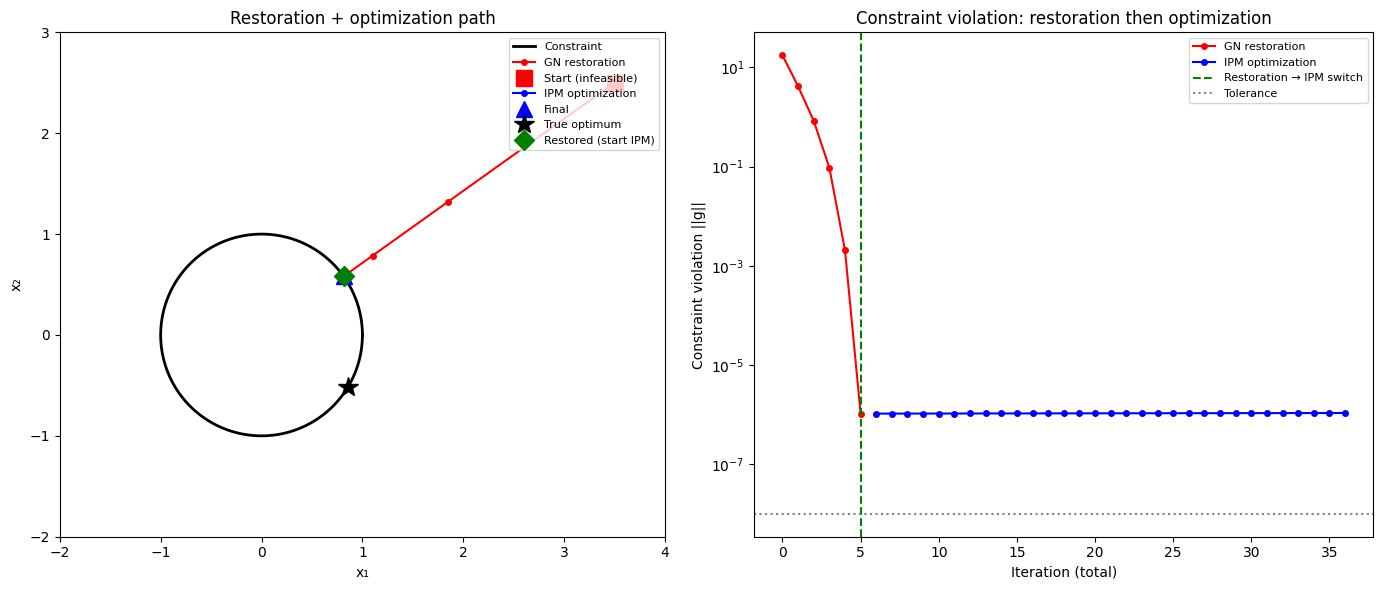

In [9]:
# Problem: min (x1-0.5)^2 + (x2+0.3)^2  s.t.  x1^2+x2^2=1
# Optimal: closest point on unit circle to (0.5, -0.3)

def f_demo(x):
    return (x[0]-0.5)**2 + (x[1]+0.3)**2

def grad_f_demo(x):
    return np.array([2*(x[0]-0.5), 2*(x[1]+0.3)])

def g_demo(x):
    return np.array([x[0]**2 + x[1]**2 - 1.0])

def jac_g_demo(x):
    return np.array([[2*x[0], 2*x[1]]])

# Start from a deeply infeasible point
x_start = np.array([3.5, 2.5])  # ||g|| = |12.25+6.25-1| = 17.5
print(f"Start: x = {x_start}, ||g|| = {np.abs(g_demo(x_start)[0]):.2f}")

# Phase 1: GN restoration
x_restored, gn_converged, gn_history = gauss_newton_restoration(
    x_start, g_demo, jac_g_demo, max_iter=50, tol=1e-10, verbose=False
)
print(f"After GN: x = {x_restored}, ||g|| = {np.abs(g_demo(x_restored)[0]):.2e}")
print(f"  GN converged: {gn_converged} in {len(gn_history)} iterations")

# Phase 2: Optimization steps from restored point
x_opt = x_restored.copy()
opt_history = [x_opt.copy()]
for k in range(30):
    J  = jac_g_demo(x_opt)
    gf = grad_f_demo(x_opt)
    gv = g_demo(x_opt)
    H  = 2 * np.eye(2)  # Hessian of f_demo
    K = np.block([[H, J.T], [J, np.zeros((1,1))]])
    rhs = np.concatenate([-gf, -gv])
    try:
        sol = np.linalg.solve(K + 1e-8*np.eye(3), rhs)
    except:
        break
    dx = sol[:2]
    # Simple backtracking
    alpha = 1.0
    for _ in range(20):
        x_new = x_opt + alpha * dx
        if np.linalg.norm(gf) * alpha < 1e-10:
            break
        cv_new = np.abs(g_demo(x_new)[0])
        cv_cur = np.abs(gv[0])
        if cv_new <= max(cv_cur * 1.001, 1e-12) and f_demo(x_new) <= f_demo(x_opt) + 1.0:
            break
        alpha *= 0.5
    x_opt = x_opt + alpha * dx
    opt_history.append(x_opt.copy())
    kkt = np.linalg.norm(gf + J.T @ sol[2:])
    cv  = np.abs(g_demo(x_opt)[0])
    if kkt < 1e-8 and cv < 1e-8:
        break

# True optimal
target = np.array([0.5, -0.3])
x_true_opt = target / np.linalg.norm(target)
print(f"\nAfter optimization: x = {x_opt}")
print(f"True optimal:       x = {x_true_opt}")
print(f"Objective: {f_demo(x_opt):.6f}  (optimal: {f_demo(x_true_opt):.6f})")

# Full visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
theta_bg2 = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta_bg2), np.sin(theta_bg2), 'k-', linewidth=2, label='Constraint')

# GN restoration path
gn_xs = np.array([h['x'] for h in gn_history])
ax.plot(gn_xs[:, 0], gn_xs[:, 1], 'r-o', markersize=4, label='GN restoration')
ax.plot(gn_xs[0, 0], gn_xs[0, 1], 'rs', markersize=12, label='Start (infeasible)')

# Optimization path
opt_xs = np.array(opt_history)
ax.plot(opt_xs[:, 0], opt_xs[:, 1], 'b-o', markersize=4, label='IPM optimization')
ax.plot(opt_xs[-1, 0], opt_xs[-1, 1], 'b^', markersize=12, label='Final')
ax.plot(*x_true_opt, 'k*', markersize=15, label='True optimum')

# Mark the restored point
ax.plot(*x_restored, 'gD', markersize=10, label='Restored (start IPM)')

ax.set_aspect('equal')
ax.set_xlim(-2, 4)
ax.set_ylim(-2, 3)
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Restoration + optimization path')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')

ax = axes[1]
thetas_gn = [h['theta'] for h in gn_history]
# Constraint violation during both phases
gn_cv = [np.abs(g_demo(h['x'])[0]) for h in gn_history]
opt_cv = [np.abs(g_demo(xv)[0]) for xv in opt_history]
n_gn = len(gn_cv)
n_opt = len(opt_cv)

ax.semilogy(range(n_gn), gn_cv, 'r-o', markersize=4, label='GN restoration')
ax.semilogy(range(n_gn, n_gn+n_opt), opt_cv, 'b-o', markersize=4, label='IPM optimization')
ax.axvline(n_gn - 1, color='g', linestyle='--', label='Restoration → IPM switch')
ax.axhline(1e-8, color='gray', linestyle=':', label='Tolerance')
ax.set_xlabel('Iteration (total)')
ax.set_ylabel('Constraint violation ||g||')
ax.set_title('Constraint violation: restoration then optimization')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Connection to ripopt

The restoration phase described here maps directly to ripopt's source:

| Concept (this notebook) | ripopt source |
|-------------------------|---------------|
| `gauss_newton_step()` | `gn_step()` in `src/restoration.rs` |
| `restoration_line_search()` | `gn_line_search()` |
| `gauss_newton_restoration()` | `run_gn_restoration()` |
| `nlp_restoration_subproblem()` | `src/restoration_nlp.rs` |
| `recovery_attempt()` | recovery loop in `src/ipm.rs` |

**Key design notes from `MEMORY.md`:**

- **Two-phase**: GN restoration first (fast), NLP restoration second (robust, at `fail_count >= 5`)
- **GN → gradient fallback**: critical for **TP262** where the Jacobian is rank-deficient
  at the infeasible starting point
- **NLP restoration structure**: `min ρ·(Σp+Σn) + (η/2)·‖D_R(x−x_r)‖²  s.t. g(x)−p+n = g_target`
  - Uses `&dyn NlpProblem` to break infinite monomorphization recursion in Rust
  - `disable_nlp_restoration=true` in inner solve prevents nesting
- **Multiplier reset** after restoration: `z` from `mu/slack`, `y` reset to 0, `v` from `mu/slack`
- **Recovery cycling**: `mu_factors = [10, 0.1, 100, 0.01, 1000, 0.001]` — TP023 required
  the x-perturbation step to escape degenerate multipliers at fail_count >= 2

In the next notebook we study **Mehrotra predictor-corrector** — a technique that makes
each IPM iteration much more effective at the cost of solving the KKT system twice.

In [10]:
# Summary test: GN restoration from multiple starting points
print("=== GN Restoration Summary ===")
print()
test_starts = [
    (np.array([3.0, 4.0]),   "far outside (r=5)"),
    (np.array([0.1, 0.1]),   "inside circle (r≈0.14)"),
    (np.array([-2.0, 0.0]),  "opposite side"),
    (np.array([1e-4, 1e-4]), "near origin (near-degenerate J)"),
]

print(f"{'Start':25s} {'||g_start||':>12} {'||g_end||':>12} {'Iters':>6} {'Conv':>6}")
print("-" * 65)
for x0, desc in test_starts:
    theta0 = np.abs(g_ex(x0)[0])
    x_r, conv, hist_r = gauss_newton_restoration(x0, g_ex, jac_g_ex,
                                                  max_iter=100, tol=1e-10)
    theta_end = np.abs(g_ex(x_r)[0])
    print(f"{desc:25s} {theta0:12.4f} {theta_end:12.2e} {len(hist_r):6d} {str(conv):>6}")

=== GN Restoration Summary ===

Start                      ||g_start||    ||g_end||  Iters   Conv
-----------------------------------------------------------------
far outside (r=5)              24.0000     9.27e-06      6   True
inside circle (r≈0.14)          0.9800     8.33e-10      4   True
opposite side                   3.0000     9.29e-08      5   True
near origin (near-degenerate J)       1.0000     3.36e-09      5   True
